<a href="https://colab.research.google.com/github/oshaajayaweera/Databases-and-Analytics/blob/main/02_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages("dplyr")
install.packages("ggplot2")

library(dplyr)
library(ggplot2)

base_url <- "https://raw.githubusercontent.com/oshaajayaweera/Databases-and-Analytics/main/"

deliveries <- read.csv(paste0(base_url, "deliveries.csv"))
hubs <- read.csv(paste0(base_url, "hubs.csv"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




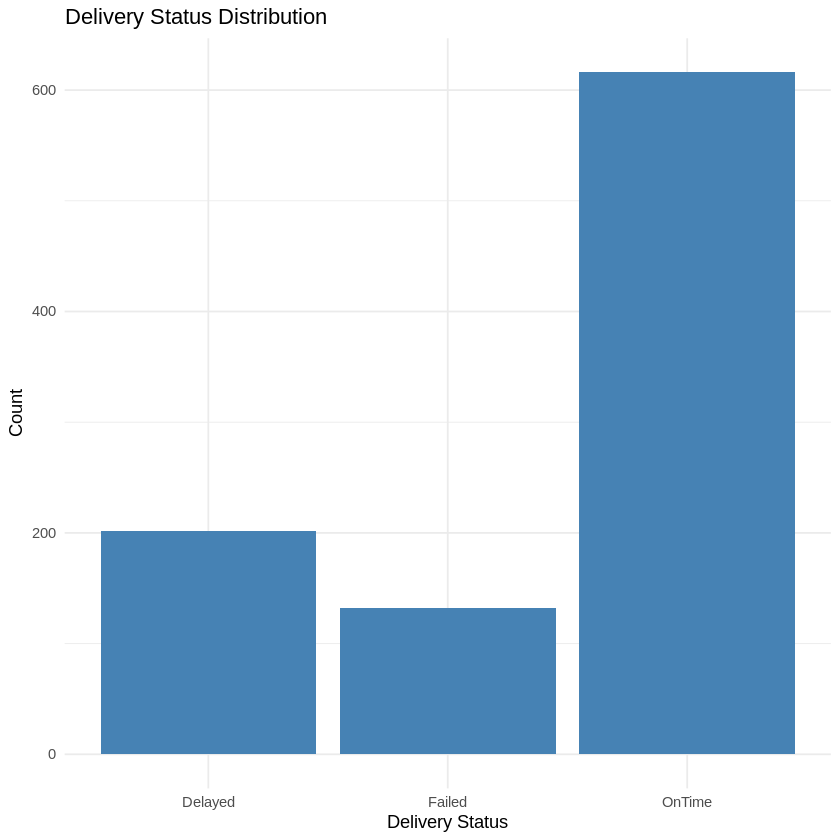

In [2]:
ggplot(deliveries, aes(x = delivery_status)) +
  geom_bar(fill = "steelblue") +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Count"
  ) +
  theme_minimal()

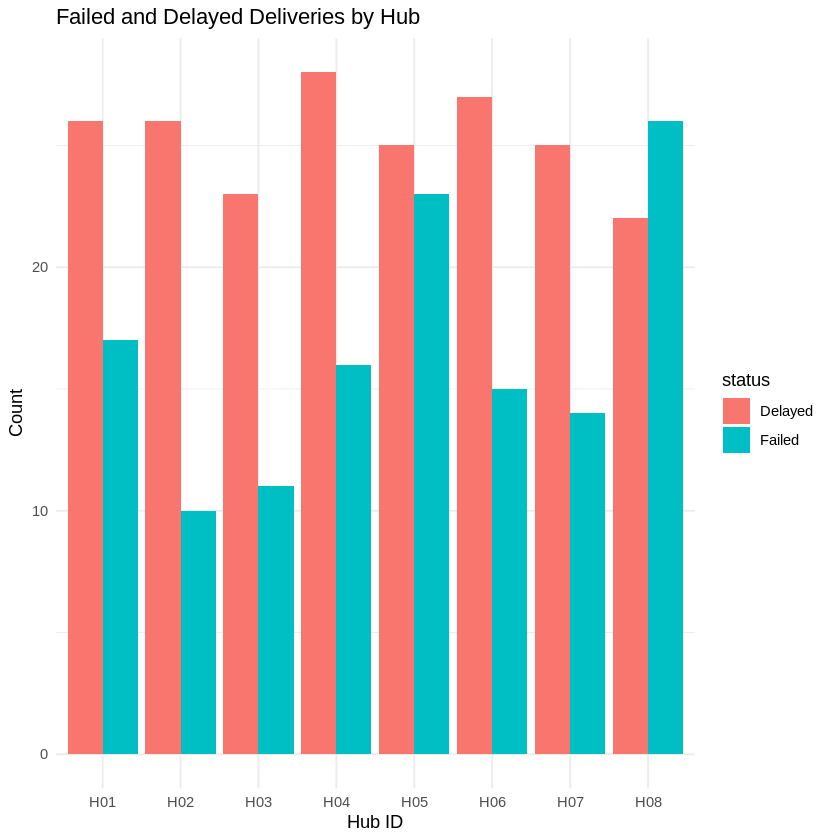

In [3]:
hub_perf <- deliveries %>%
  group_by(hub_id) %>%
  summarise(
    failed = sum(delivery_status == "Failed", na.rm = TRUE),
    delayed = sum(delivery_status == "Delayed", na.rm = TRUE)
  )

hub_perf_long <- data.frame(
  hub_id = rep(hub_perf$hub_id, 2),
  status = rep(c("Failed", "Delayed"), each = nrow(hub_perf)),
  count = c(hub_perf$failed, hub_perf$delayed)
)

ggplot(hub_perf_long, aes(x = hub_id, y = count, fill = status)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Failed and Delayed Deliveries by Hub",
    x = "Hub ID",
    y = "Count"
  ) +
  theme_minimal()

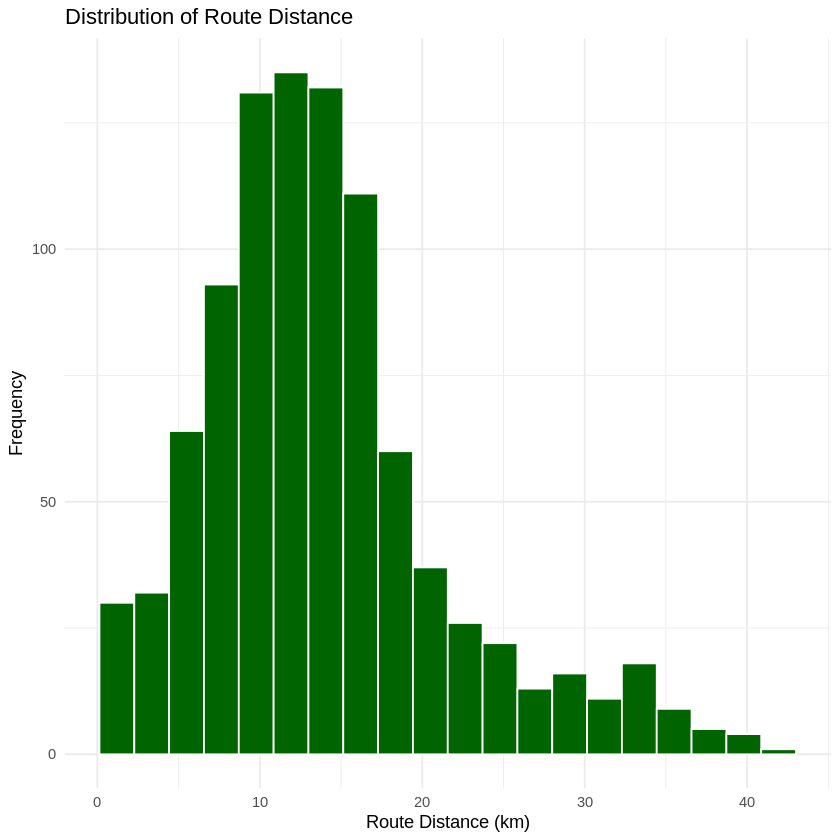

In [4]:
ggplot(deliveries, aes(x = route_distance_km)) +
  geom_histogram(bins = 20, fill = "darkgreen", color = "white") +
  labs(
    title = "Distribution of Route Distance",
    x = "Route Distance (km)",
    y = "Frequency"
  ) +
  theme_minimal()

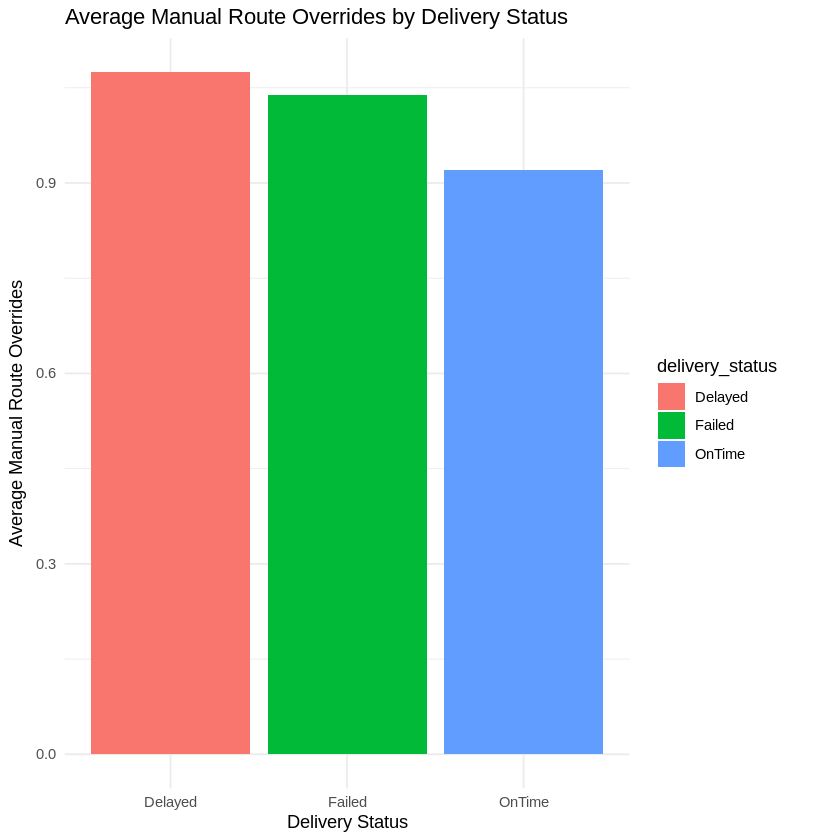

In [5]:
override_summary <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(avg_override = mean(manual_route_override_count, na.rm = TRUE))

ggplot(override_summary, aes(x = delivery_status, y = avg_override, fill = delivery_status)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Average Manual Route Overrides by Delivery Status",
    x = "Delivery Status",
    y = "Average Manual Route Overrides"
  ) +
  theme_minimal()

Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


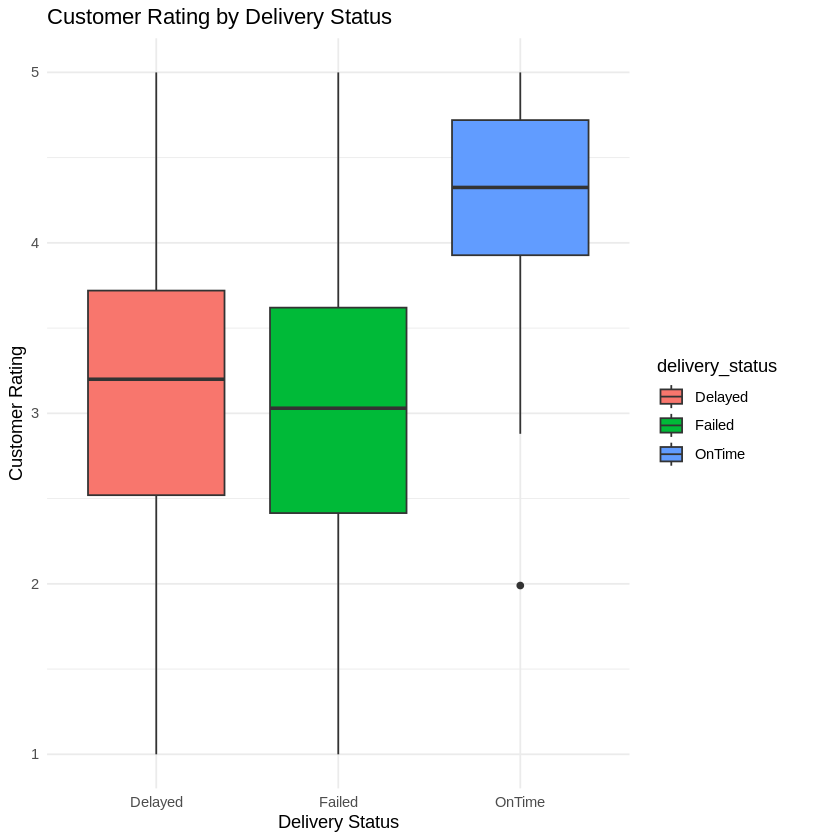

In [6]:
ggplot(deliveries, aes(x = delivery_status, y = customer_rating_post_delivery, fill = delivery_status)) +
  geom_boxplot() +
  labs(
    title = "Customer Rating by Delivery Status",
    x = "Delivery Status",
    y = "Customer Rating"
  ) +
  theme_minimal()